=============================================================================

Sentiment Analysis of Tweets using Transformer (DistilBert)

=============================================================================

PART 2: Fine-Tuning a transformer model
Here the 'manually_labelled_tweets.csv' is now being used that contains the final, manually corrected sentiment labels.

In [1]:
# Importing All Necessary Libraries
import pandas as pd
import numpy as np
import random
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification

c:\Users\Tatha\anaconda3\envs\twitter-sentiment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'TFDistilBertForSequenceClassification' from 'transformers' (c:\Users\Tatha\anaconda3\envs\twitter-sentiment\Lib\site-packages\transformers\__init__.py)

In the seed code below I have tried to keep the performance of the model same by removing the randomness and fixing the seed. So that the result in my report and on running the code matches.

In [29]:
# Setting Random Seeds for Reproducible same robust results

seed_value = 50
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

In [30]:
# Loading the manually corrected dataset
try:
    df = pd.read_csv('manually_labelled_tweets.csv')
    df['text'] = df['text'].astype(str) # Ensuring all tweet text is a string
    print(f"Successfully loaded manually corrected dataset with {len(df)} tweets.")
except Exception as e:
    print(f"Error loading dataset: {e}")

Successfully loaded manually corrected dataset with 1965 tweets.


In [31]:
# Preprocessing the text data

def preprocess_text(text):
    text = str(text)  # Converts the input to a string in case it is not already one
    text = re.sub(r'http\S+|www\S+', ' ', text)  # Removes URLs starting with http, https, or www
    text = re.sub(r'@\w+', ' @user ', text)  # Replaces @mentions with a generic placeholder token
    text = re.sub(r'#(\w+)', r'\1', text)  # Removes the # symbol but keeps the hashtag word itself
    text = re.sub(r'\s+', ' ', text).strip()  # Collapses multiple spaces into one and trims leading/trailing spaces
    return text
df['cleaned_text'] = df['text'].apply(preprocess_text)
print("Preprocessing complete.")

Preprocessing complete.


In [33]:
# Preparing data for the model for training
texts = df['cleaned_text'].tolist() #sepearting texts
labels = df['classification'].tolist() #seperating the classification data

# splitting the data into a training set and a testing set.
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
print("Data has been split.")

Data has been split.


In [34]:
# Tokenization and padding
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)

# here the Hugging Face tokenizer is tokenizing, truncating and padding
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)
print("Tokenization and padding of data complete.")

c:\Users\Tatha\anaconda3\envs\my_projects\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Tokenization and padding of data complete.


In [35]:
# Creating TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), test_labels))
print("Created TensorFlow datasets for efficient training.")

Created TensorFlow datasets for efficient training.


In [36]:
# Loading the Pre-Trained Transformer model DistilBERT
model = TFDistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

# compiling the model.
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5) #using Adam optimizer
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
model.compile(optimizer=optimizer, loss=loss, metrics=[metric])
print("Pre-trained DistilBERT model loaded and compiled successfully.")
model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Pre-trained DistilBERT model loaded and compiled successfully.
Model: "tf_distil_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
 dropout_19 (Dropout)        multiple                  0 (unused)
                                                                 
Total params: 66955010 (255.41 MB)
Trainable params: 66955010 (255.41 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________

In [37]:
# Training the model

# using EarlyStopping to prevent overfitting.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)
history = model.fit(train_dataset.shuffle(1000, seed=seed_value).batch(16),
                    epochs=10,
                    validation_data=test_dataset.batch(16),
                    callbacks=[early_stopping])
print("\nModel fine-tuning complete.")

Epoch 1/10

99/99 [==============================] - 380s 4s/step - loss: 0.5337 - accuracy: 0.7316 - val_loss: 0.3399 - val_accuracy: 0.8702
Epoch 2/10
99/99 [==============================] - 295s 3s/step - loss: 0.2867 - accuracy: 0.8893 - val_loss: 0.2826 - val_accuracy: 0.8880
Epoch 3/10
99/99 [==============================] - 416s 4s/step - loss: 0.1619 - accuracy: 0.9459 - val_loss: 0.3964 - val_accuracy: 0.8702

Model fine-tuning complete.


Final Test Accuracy: 88.80%
25/25 [==============================] - 27s 792ms/step
<class 'numpy.ndarray'>

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.91      0.89       202
    Positive       0.90      0.86      0.88       191

    accuracy                           0.89       393
   macro avg       0.89      0.89      0.89       393
weighted avg       0.89      0.89      0.89       393


Confusion Matrix:


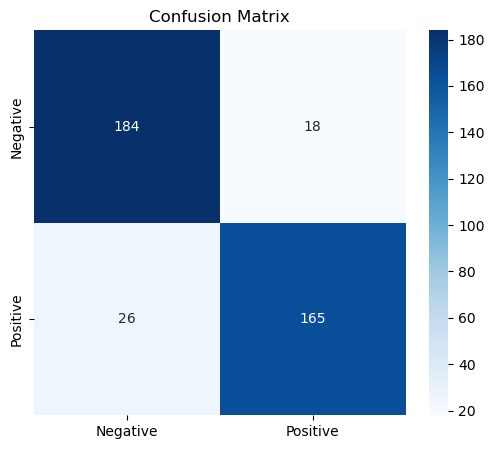

In [38]:
# Evaluating the model's performance

test_loss, test_accuracy = model.evaluate(test_dataset.batch(16), verbose=0)
print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")

# getting predictions for test set
test_predictions_logits = model.predict(test_dataset.batch(16)).logits
test_predictions = np.argmax(test_predictions_logits, axis=1)
print(type(test_predictions))
# Now, print the reports.
print("\nClassification Report:")
print(classification_report(test_labels, test_predictions, target_names=['Negative', 'Positive']))

print("\nConfusion Matrix:")
cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.show()


Visualizing Training History...


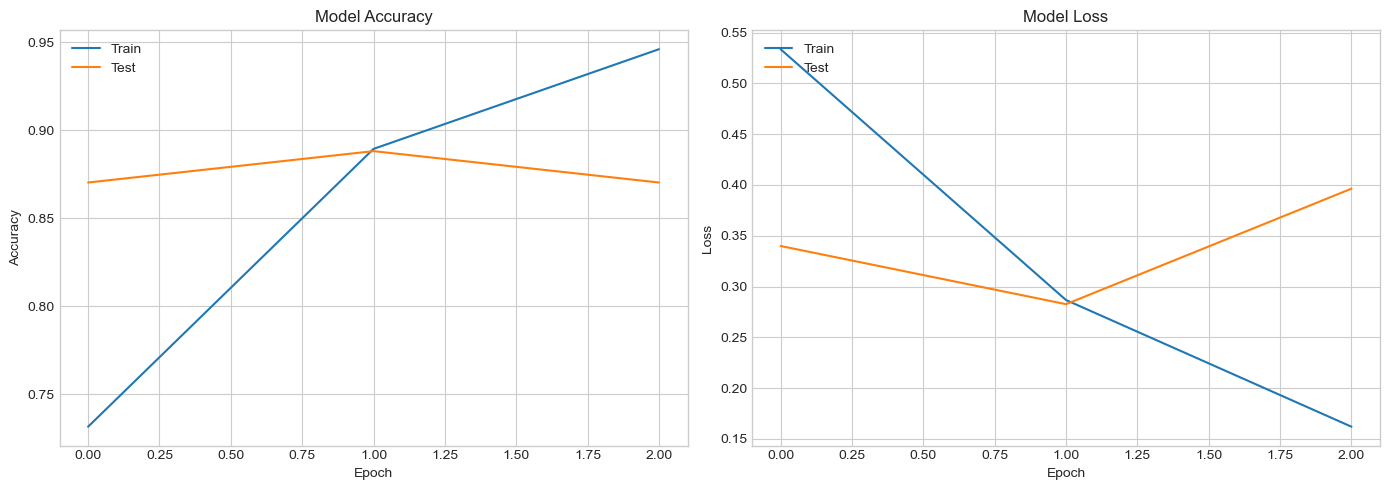

In [39]:
# Visualizing the learning process (train and test curves)

print("\nVisualizing Training History...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# training & validation accuracy values
ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Test'], loc='upper left')

# training & validation loss values
ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

In [40]:
# Creating a Prediction function for new inputs

def predict_sentiment_transformer(text):
    inputs = tokenizer(text, return_tensors="tf", truncation=True, padding=True, max_length=128)
    logits = model(inputs).logits
   #getting the class with highest score(that is prediction value)
    predicted_class_id = int(tf.math.argmax(logits, axis=-1)[0])
    return "Positive" if predicted_class_id == 1 else "Negative"

In [41]:
# Prediction user interface (CLI)
while True:
    user_input = input("Enter a sentence to analyze, or type 'quit' to exit:")
    if user_input.lower() == 'quit':
        break
    #calling the prediction function
    sentiment = predict_sentiment_transformer(user_input)
    print(f"Predicted Sentiment: {sentiment}")

Predicted Sentiment: Negative
Predicted Sentiment: Negative
Predicted Sentiment: Negative
Predicted Sentiment: Negative
Predicted Sentiment: Positive
Predicted Sentiment: Positive
